# Business Understanding

## Project Domain

Domain: Churn Modelling<br>
Sub-Domain: Customer Churn Prediction<br>
Customer Churn Prediction System termasuk dalam bidang analitik pelanggan yang memanfaatkan data science dan machine learning untuk membantu perusahaan dalam mengidentifikasi pelanggan yang berpotensi berhenti menggunakan layanan mereka (churn). Dengan mempelajari pola historis interaksi pelanggan dan atribut demografis, model prediktif seperti Artificial Neural Network (ANN) dapat digunakan untuk memprediksi kemungkinan churn sehingga perusahaan dapat mengambil tindakan preventif.

## Problem Statements

Masalah yang Dihadapi:
1. Ketidaktepatan dalam Mengidentifikasi Pelanggan yang Berpotensi Churn
- Banyak perusahaan kesulitan dalam mengidentifikasi pelanggan yang berpotensi untuk berhenti menggunakan layanan mereka.
- Tanpa alat prediktif yang tepat, perusahaan seringkali baru mengetahui bahwa pelanggan mereka churn setelah mereka benar-benar berhenti, yang sudah terlambat untuk mengambil tindakan preventif.

2. Ketergantungan pada Pengamatan Manual
- Banyak perusahaan masih mengandalkan pengamatan manual atau pengalaman dari tenaga pemasaran untuk mengidentifikasi pelanggan yang berisiko churn.
- Pendekatan ini sangat rentan terhadap bias dan tidak selalu didasarkan pada data yang akurat dan objektif, sehingga dapat menghasilkan keputusan yang kurang efektif dalam menangani pelanggan.

3. Perubahan Perilaku Pelanggan yang Tidak Terduga
- Perilaku pelanggan dapat berubah secara tiba-tiba akibat faktor eksternal seperti perubahan ekonomi, kompetisi baru, atau perubahan dalam kebutuhan dan preferensi pelanggan.
-Tanpa sistem yang dapat memprediksi perubahan ini, perusahaan kesulitan dalam merespons perubahan tersebut dengan cepat dan tepat.

4. Biaya Tinggi dalam Mempertahankan Pelanggan
- Usaha untuk mempertahankan pelanggan yang berisiko churn seringkali memerlukan biaya yang tinggi, seperti pemberian diskon besar atau promosi yang tidak selalu efektif.
- Tanpa pemahaman yang baik tentang pelanggan mana yang benar-benar berisiko, perusahaan dapat menghabiskan sumber daya yang banyak untuk mencoba mempertahankan pelanggan yang pada akhirnya tetap akan churn.

## Goals

Goals :
1. Membangun Sistem Prediksi Churn yang Akurat
- Mengembangkan model Artificial Neural Network (ANN) yang dapat memprediksi kemungkinan pelanggan akan berhenti menggunakan layanan (churn) berdasarkan data historis pelanggan, termasuk informasi demografis, riwayat penggunaan layanan, interaksi dengan perusahaan, dan faktor lainnya yang mempengaruhi keputusan mereka untuk tetap atau berhenti.

2. Meningkatkan Retensi Pelanggan
- Dengan memprediksi pelanggan yang berisiko churn, sistem ini memungkinkan perusahaan untuk mengambil langkah-langkah proaktif dalam mempertahankan pelanggan, seperti menawarkan insentif, diskon, atau layanan yang lebih baik, sebelum mereka benar-benar berhenti.

3. Optimalisasi Sumber Daya untuk Retensi Pelanggan
- Mengurangi biaya yang tidak perlu untuk mempertahankan pelanggan yang tidak benar-benar berisiko churn dengan menargetkan hanya pelanggan yang benar-benar membutuhkan perhatian. Dengan sistem ini, perusahaan dapat mengalokasikan sumber daya yang lebih efisien.

4. Personalisasi Pengalaman Pelanggan
- Dengan menganalisis pola perilaku pelanggan, sistem dapat memberikan wawasan yang lebih dalam tentang preferensi pelanggan, yang memungkinkan perusahaan untuk menyesuaikan penawaran dan pengalaman pelanggan dengan lebih tepat.

## Solution Statements

1. Machine Learning Model
- Menggunakan Artificial Neural Network (ANN) untuk mengklasifikasikan pelanggan yang berisiko churn berdasarkan dataset atribut pelanggan (misalnya, usia, status pernikahan, durasi berlangganan, penggunaan layanan, dll.). Model ini dilatih dengan tujuan untuk memprediksi kemungkinan churn dengan akurasi tinggi (>80%) dan memberikan wawasan yang berguna bagi perusahaan untuk mengidentifikasi pelanggan yang membutuhkan perhatian lebih.

2. Aplikasi Web (Streamlit)
- Membuat antarmuka yang mudah digunakan bagi tim pemasaran atau customer support untuk memasukkan data pelanggan dan mendapatkan prediksi churn secara instan. Aplikasi ini memungkinkan pengguna untuk melihat status pelanggan, tingkat risiko churn, dan memberikan rekomendasi tindakan yang dapat diambil untuk mempertahankan pelanggan yang berisiko.

3. Optimasi dengan TensorFlow Lite
- Model yang telah dilatih akan dikonversi ke format TensorFlow Lite (TFLite), sehingga lebih ringan dan dapat dijalankan di perangkat dengan sumber daya terbatas seperti smartphone atau tablet. Ini memungkinkan tim lapangan atau staf yang bekerja di lokasi untuk menggunakan model prediksi churn secara langsung tanpa memerlukan koneksi internet yang stabil atau perangkat komputasi yang kuat.

# Data Understanding

## Import data dari kaggle

In [130]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"salikelhanan","key":"8c78d265a9ab5dd0d36759cb51d48e31"}'}

In [131]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [132]:
!kaggle datasets download shubh0799/churn-modelling

Dataset URL: https://www.kaggle.com/datasets/shubh0799/churn-modelling
License(s): CC0-1.0
churn-modelling.zip: Skipping, found more recently modified local copy (use --force to force download)


In [133]:
!mkdir churn-modelling
!unzip churn-modelling.zip -d churn-modelling
!ls churn-modelling

mkdir: cannot create directory ‘churn-modelling’: File exists
Archive:  churn-modelling.zip
replace churn-modelling/Churn_Modelling.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Churn_Modelling.csv


## Import Library yang dibutuhkan

In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [146]:
df = pd.read_csv('/content/churn-modelling.zip')

In [147]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [137]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [139]:
# Isi missing value dengan median
df.fillna(df.median(numeric_only=True), inplace=True)

In [140]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


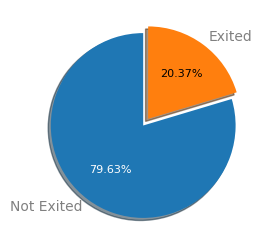

In [141]:
values = df.Exited.value_counts()
labels = ['Not Exited', 'Exited']

fig, ax = plt.subplots(figsize = (4, 3), dpi = 100)
explode = (0, 0.09)

patches, texts, autotexts = ax.pie(values, labels = labels, autopct = '%1.2f%%', shadow = True,
                                   startangle = 90, explode = explode)

plt.setp(texts, color = 'grey')
plt.setp(autotexts, size = 8, color = 'white')
autotexts[1].set_color('black')
plt.show()

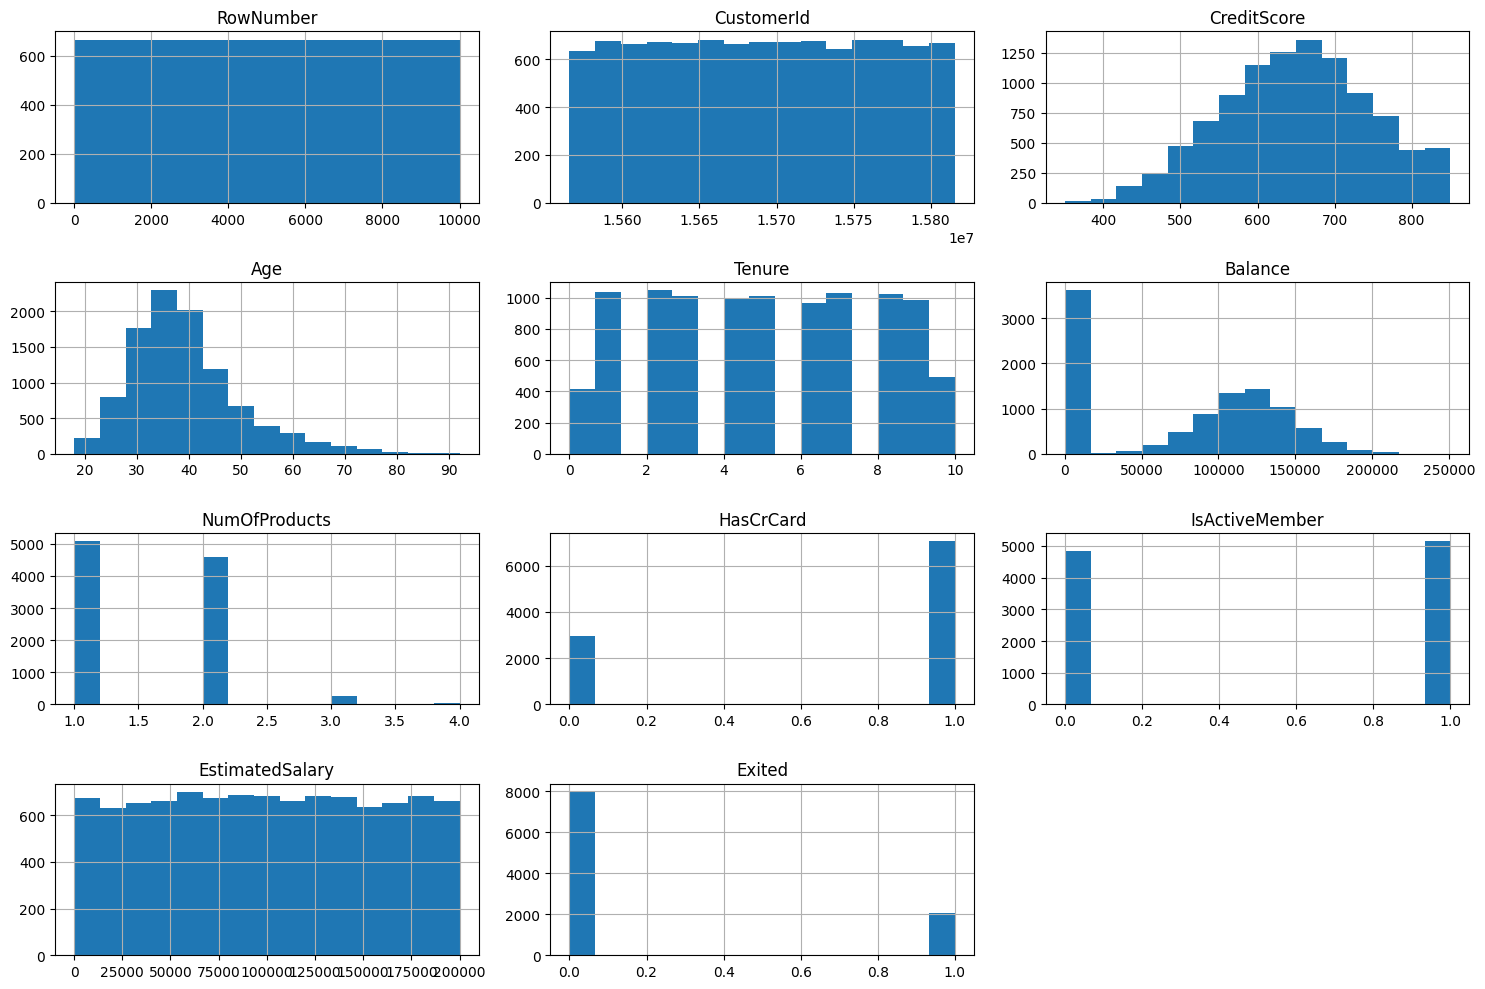

In [142]:
# Numerical features distribution
df.hist(figsize=(15, 10), bins=15)
plt.tight_layout()
plt.show()

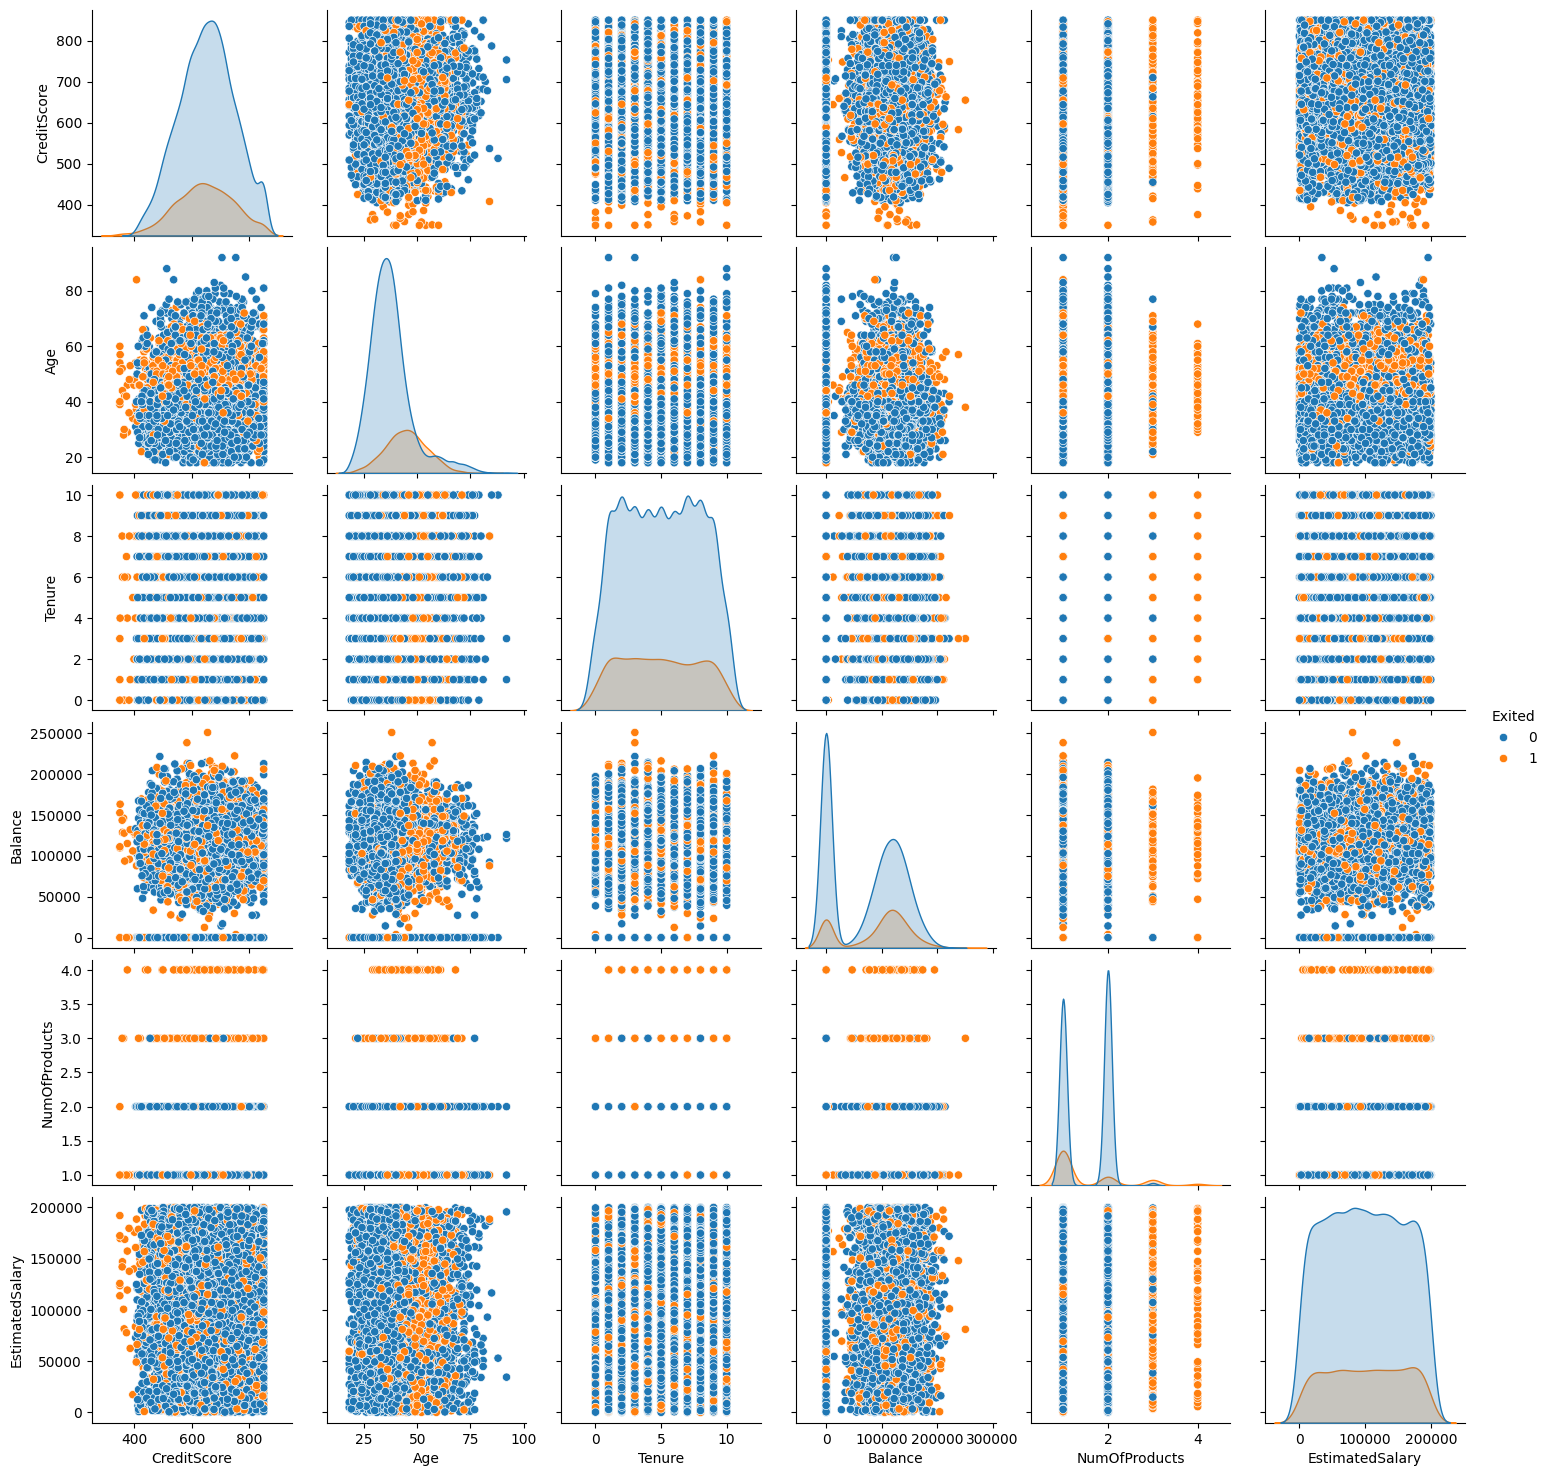

In [143]:
# Pairplot for selected numerical features
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
sns.pairplot(df[numerical_features + ['Exited']], hue='Exited', diag_kind='kde')
plt.show()

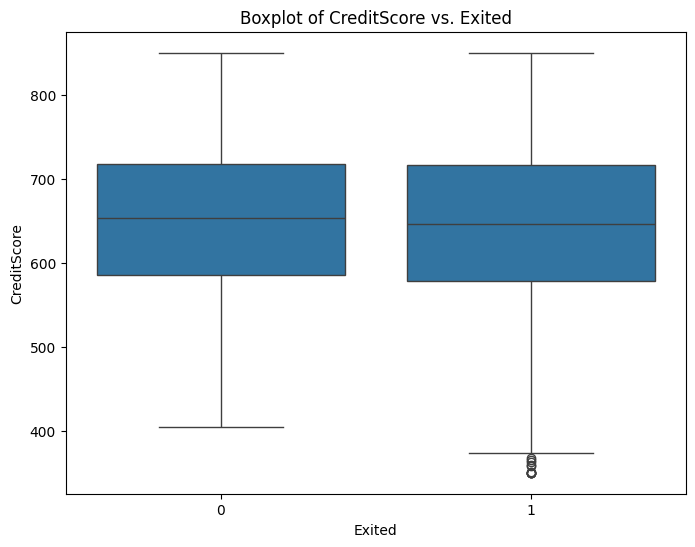

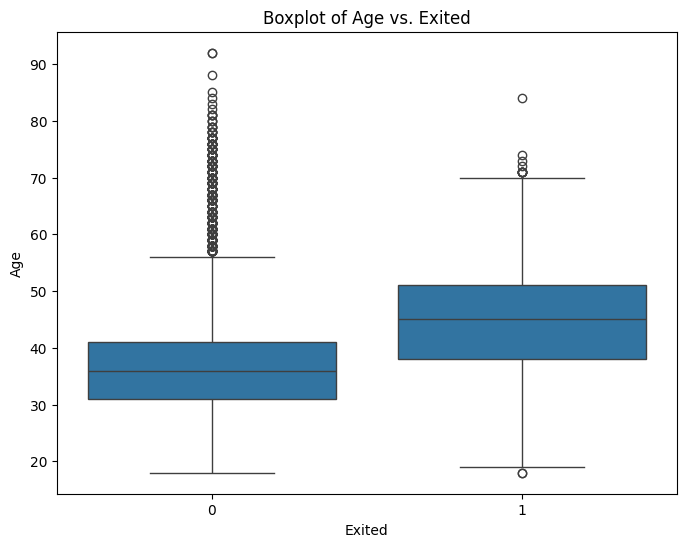

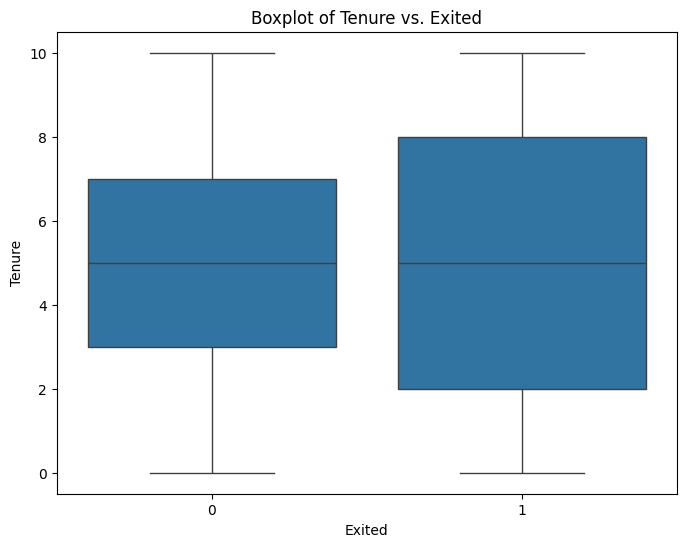

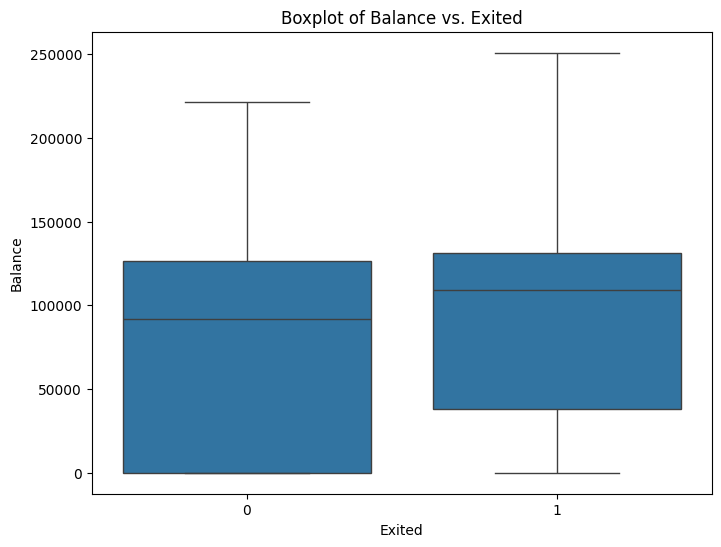

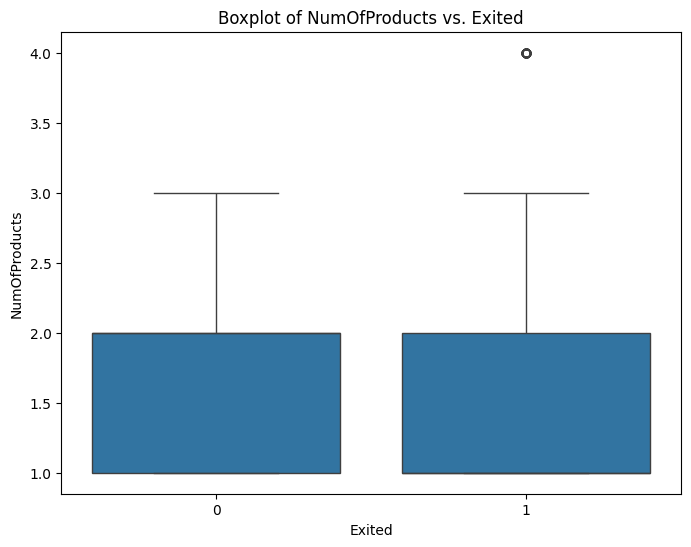

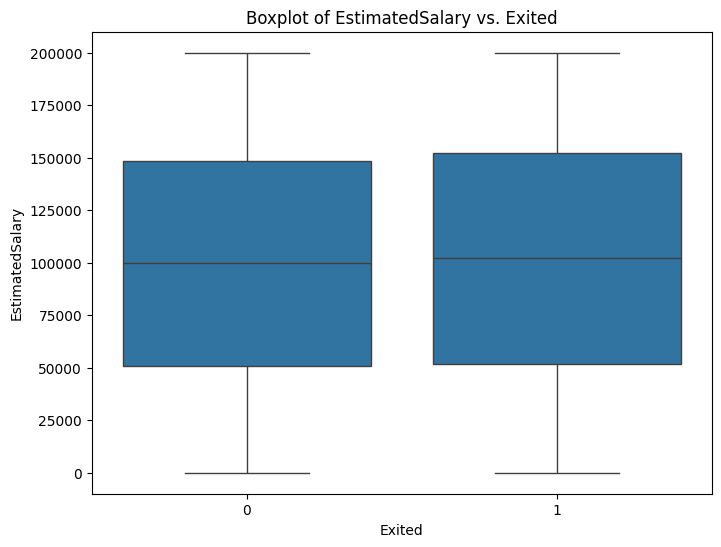

In [144]:
for col in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f'Boxplot of {col} vs. Exited')
    plt.show()

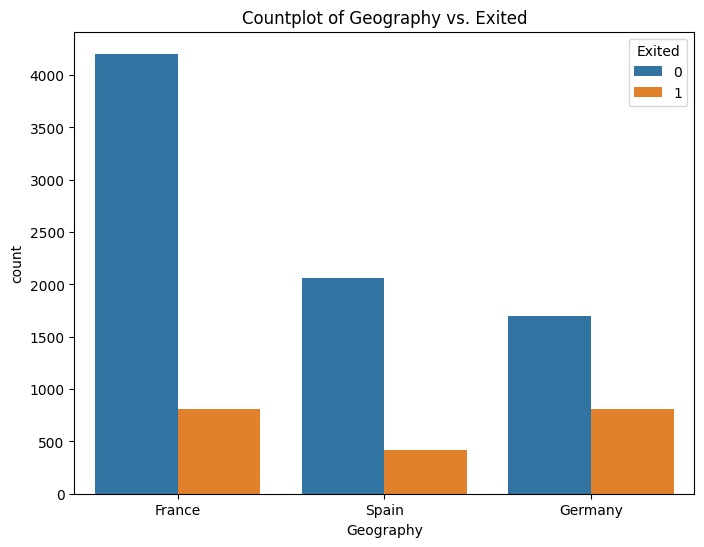

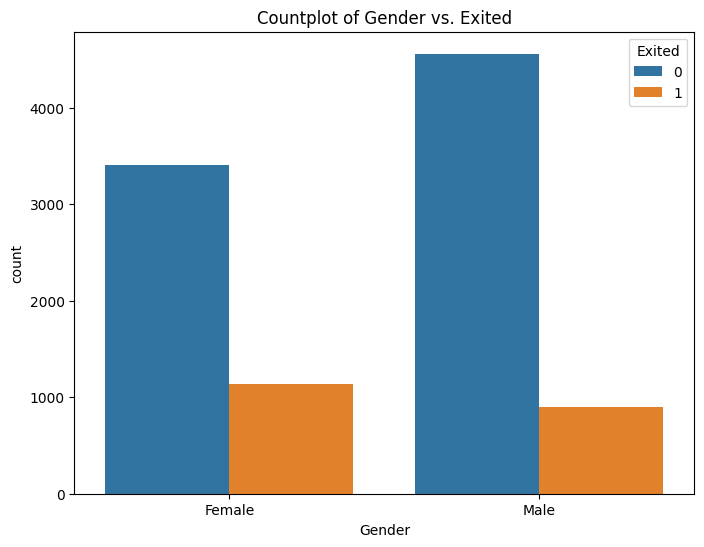

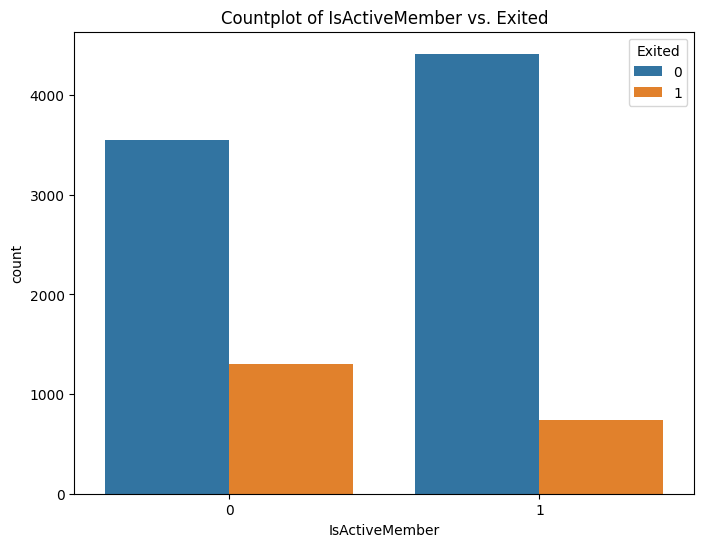

In [145]:
# Countplots for categorical features vs. Exited
categorical_features = ['Geography', 'Gender', 'IsActiveMember']
for col in categorical_features:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, hue='Exited', data=df)
    plt.title(f'Countplot of {col} vs. Exited')
    plt.show()

# Data Preparation

In [148]:
#drop colom tidak terpakai
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], axis = 1, inplace = True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [149]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Geography'] = df['Geography'].map({'France': 0, 'Spain': 1, 'Germany': 2})


In [150]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,0,43,2,125510.82,1,1,1,79084.10,0


In [152]:
# Pisahkan fitur dan target
X = df.drop('Exited', axis=1)
y = df['Exited']

In [154]:
#encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [155]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [156]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [157]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [158]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [159]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,810 (46.13 KB)

 Trainable params: 11,810 (46.13 KB)

 Non-trainable params: 0 (0.00 B)

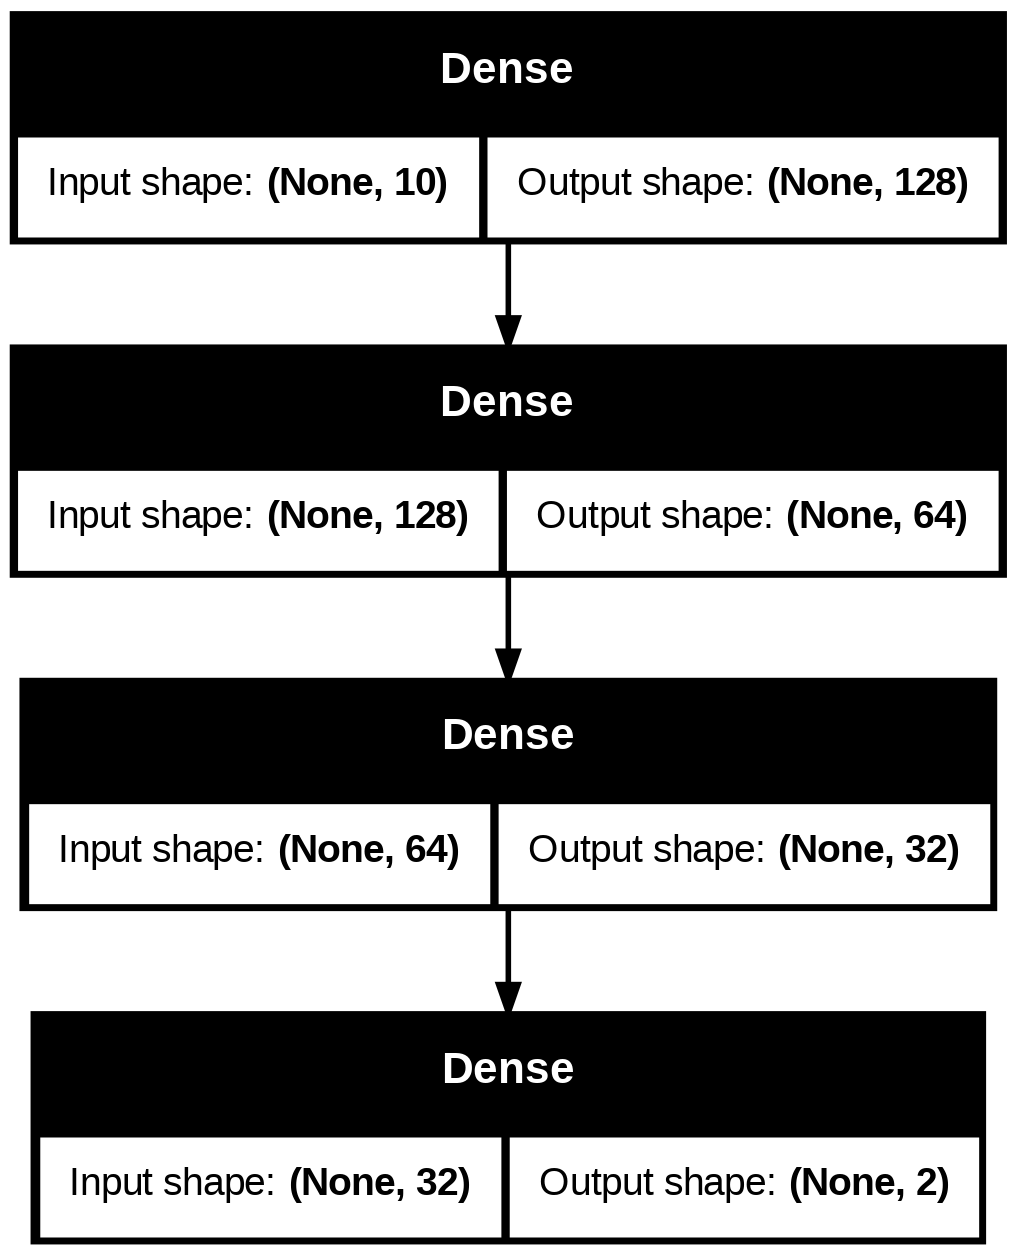

In [160]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [161]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7917 - loss: 0.4907 - val_accuracy: 0.8230 - val_loss: 0.4106
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8265 - loss: 0.4056 - val_accuracy: 0.8525 - val_loss: 0.3659
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8483 - loss: 0.3677 - val_accuracy: 0.8500 - val_loss: 0.3586
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8524 - loss: 0.3679 - val_accuracy: 0.8545 - val_loss: 0.3656
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - loss: 0.3523 - val_accuracy: 0.8625 - val_loss: 0.3505
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8599 - loss: 0.3446 - val_accuracy: 0.8590 - val_loss: 0.3482
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8644 - loss: 0.3391 - val_accuracy: 0.8595 - val_loss: 0.3496
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8681 - loss: 0.3293 - val_accuracy: 0.

# Evaluation

In [163]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8585 - loss: 0.3750
Akurasi Model: 0.8505
Loss Model: 0.3971


In [164]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

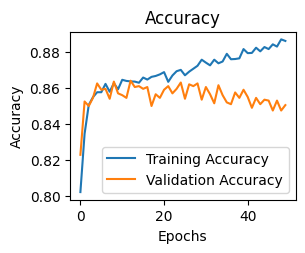

In [165]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

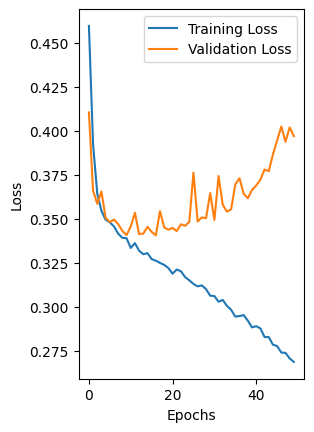

In [166]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


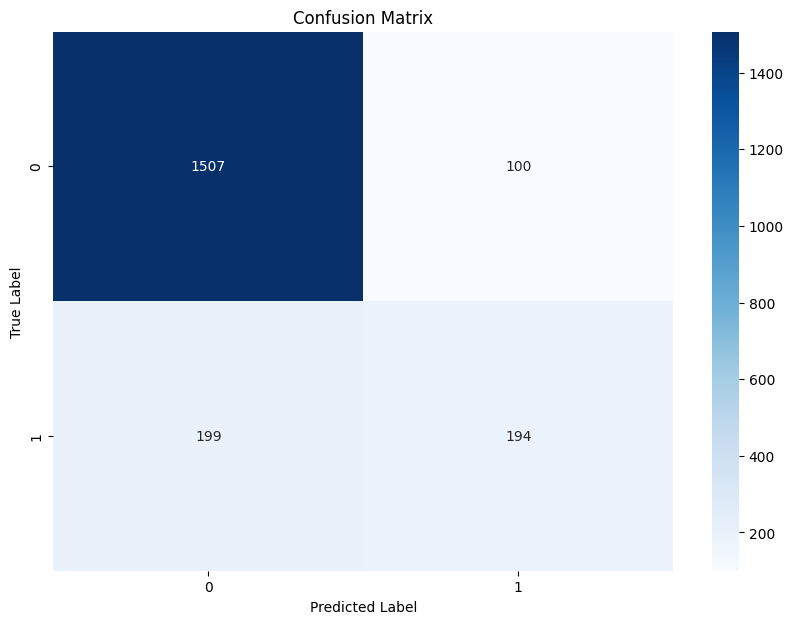

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.66      0.49      0.56       393

    accuracy                           0.85      2000
   macro avg       0.77      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



In [167]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [168]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,0,43,2,125510.82,1,1,1,79084.10,0


In [169]:
sample_input = np.array([[550, 2 ,1, 23, 2,	0.00, 3, 1, 1, 1111.1,]])
sample_input_df = pd.DataFrame(sample_input)

In [174]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [175]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Status Nasabah: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Status Nasabah: 0


## Save Model

In [179]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('churn_modelling.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp8disvclx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138640949524816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640949524048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640949526352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640949522320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640949512336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640949519632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640498445968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138640498455568: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [178]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']